    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 10: Implement a program which, given (a) a label l, (b) a user selected 
    latent semantics, and (c) positive integer k, identifies and lists k most relevant
    images, along with their scores, under the selected latent space.

In [10]:
# Input take label, latent semantics and k
LABEL_INPUT = input(
"""
Provide the label for which you want to find most similar images
"""
)

LATENT_SEMANTICS = input(
"""
Provide a latent semantic that was generated using tasks 3 to 6.
For eg:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_svd" if you generated it for tasks where you didn't select the algorithm,
use this format "LS3_color"
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

K = int(input("Enter K, the K most similar images to find under the latent space."))

In [11]:
import numpy as np
from utils.database_utils import retrieve
from utils.distance_utils import top_k_distance_ranker, get_distance_fn
from utils.database_utils import compressed_retrieve
from scipy.spatial.distance import cityblock, correlation, cosine, euclidean
from feature_models.feature_matrix.label_label_similarity import LabelLabelSimilarity

In [12]:
from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

Files already downloaded and verified


In [13]:
LATENT_SPACE = LATENT_SEMANTICS.split('_')[0]
FEATURE_SPACE = LATENT_SEMANTICS.split('_')[1]

# Load created latent space
reducer = retrieve(f'{LATENT_SEMANTICS}_reducer.pt')

feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')

In [19]:
def find_nearest_cluster(vector, query_vector, K):
    distance_fn = get_distance_fn(FEATURE_SPACE)
    distance = []
    for i, feature_item in enumerate(vector.items()):
        image_id, feature_tuple = feature_item
        label = feature_tuple[0]
        current_vector = feature_tuple[1]
        distance.append((image_id, distance_fn(query_vector, current_vector)))
    distance.sort(key=lambda x:x[1])
    return distance[:K]

In [20]:
def get_distances_for_image_latent_space(latent_space):
    centroid_format_latent_space = {}
    for i, feature_item in enumerate(feature_vectors.items()):
        image_id, feature_tuple = feature_item
        label = feature_tuple[0]
        feature = latent_space[i]
        centroid_format_latent_space[image_id] = (label, feature)

    # Find centroids for the labels
    from utils.vector_utils import get_representative_vectors_for_labels
    from utils.dataset_utils import initialize_dataset

    centroids = get_representative_vectors_for_labels(centroid_format_latent_space, initialize_dataset().categories, 1)

    # Find closest labels based on distance
    distances = find_nearest_cluster(centroid_format_latent_space, centroids[LABEL_INPUT], K)
    return distances

In [21]:
if LATENT_SPACE == "LS1":
    # For LS1 find labels for every image in the latent space
    latent_space = reducer.reduce_features(feature_vectors)
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

elif LATENT_SPACE == "LS2":
    # For LS2 find labels for every image in the latent space
    latent_space = reducer.get_image_weight()
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

elif LATENT_SPACE == "LS3":
    # For LS3
    # Get label feature space
    all_labels = initialize_dataset().categories
    label_feature_vectors = retrieve(f'label_label_{FEATURE_SPACE}.pt')

    from utils.vector_utils import get_latent_feature_vectors
    latent_feature_vectors = get_latent_feature_vectors(label_feature_vectors, reducer)

    rep_label_vectors = retrieve(f'rep_label_{FEATURE_SPACE}.pt')

    # Create image label similarity vector
    # for every image in feature vectors
    from utils.vector_utils import get_image_label_similarity_vector
    image_label_feature_space = []
    for i, feature_item in enumerate(feature_vectors.items()):
        image_id, feature_tuple = feature_item
        vector = feature_tuple[1]
        img_label_vector = get_image_label_similarity_vector(vector, rep_label_vectors, all_labels)
        image_label_feature_space.append(img_label_vector)
    image_label_feature_space = np.array(image_label_feature_space)

    # Reduce dimensions for the image label similarity vector and make it into feature vector format
    latent_vector_image_label = reducer.reduce_features({"QUERY": ("UNKNOWN", image_label_feature_space)})[0]
    centroid_format_latent_space = {}
    for i, feature_item in enumerate(feature_vectors.items()):
        image_id, feature_tuple = feature_item
        label = feature_tuple[0]
        feature = latent_vector_image_label[i]
        centroid_format_latent_space[image_id] = (label, feature)

    # Find selected label center
    # First we get label label reduced dimension and then we find the label center we want
    latent_vector_label_label = reducer.reduce_features(label_feature_vectors)
    reference_label_vector = []
    for index, label in enumerate(all_labels):
        if label == LABEL_INPUT:
            reference_label_vector = latent_vector_label_label[index]

    # Find distance between the selected label center and the entire image latent space
    distances = find_nearest_cluster(centroid_format_latent_space, reference_label_vector, K)
    print(distances)
else:
    image_feature_vectors = compressed_retrieve(f'img_img_{FEATURE_SPACE}.pt')
    latent_space = reducer.reduce_features(image_feature_vectors)
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

Files already downloaded and verified
[(8606, 1.1168350994128495e-05), (8592, 1.2961572133041166e-05), (6328, 2.0767319230508008e-05), (8600, 2.451528751268306e-05), (4640, 2.67916182030703e-05), (8590, 2.8705280286978052e-05), (8614, 2.9504193320706307e-05), (4596, 3.0228920696373507e-05), (8604, 3.5745889627403216e-05), (8610, 3.812466759633981e-05)]



K = 10 most similar images by LS2_fc_cpd latent semantics
Image Id: 8606 		Distance Score: 1.1168350994128495e-05


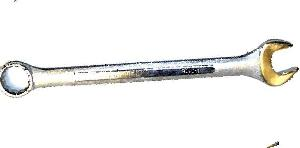

Image Id: 8592 		Distance Score: 1.2961572133041166e-05


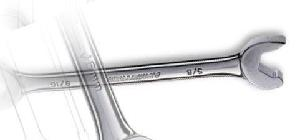

Image Id: 6328 		Distance Score: 2.0767319230508008e-05


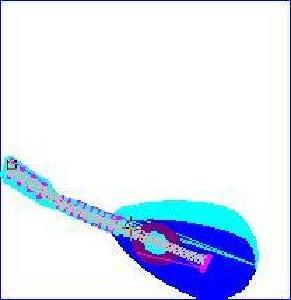

Image Id: 8600 		Distance Score: 2.451528751268306e-05


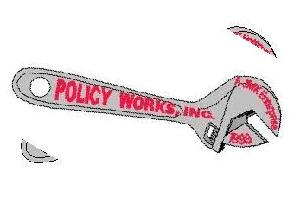

Image Id: 4640 		Distance Score: 2.67916182030703e-05


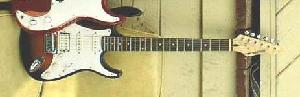

Image Id: 8590 		Distance Score: 2.8705280286978052e-05


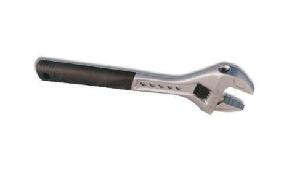

Image Id: 8614 		Distance Score: 2.9504193320706307e-05


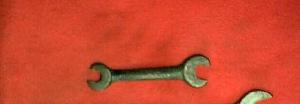

Image Id: 4596 		Distance Score: 3.0228920696373507e-05


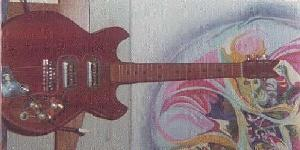

Image Id: 8604 		Distance Score: 3.5745889627403216e-05


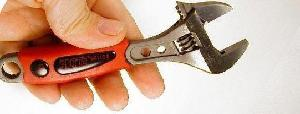

Image Id: 8610 		Distance Score: 3.812466759633981e-05


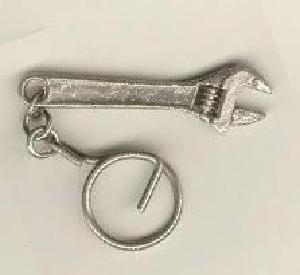

In [22]:
print("\nK =", K, "most similar images by", LATENT_SEMANTICS, "latent semantics")

for i in range(len(distances)):
    image_id = distances[i][0]
    distance = distances[i][1]
    print("Image Id:", image_id, "\t\tDistance Score:", distance)
    display(dataset[image_id][0])